# Whakaari Cause-Trigger Analysis

This notebook applies the Cause-Trigger workflow to the Whakaari 2019 eruption case study. The full dataset is loaded as the constructed data product, but the algorithm is run only on a fixed case-study interval around the eruption.

The split into \(I_1\) and \(I_2\) is selected automatically from the effect variable. The known eruption time is shown only for physical interpretation.

## 1. Imports, paths, and case-study interval

In [ ]:
from pathlib import Path
import sys
import warnings
import pandas as pd

warnings.filterwarnings("ignore", message="No frequency information was provided")
warnings.filterwarnings("ignore", message="A date index has been provided")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="An input array is constant")

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 40)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import (
    COMPACT_RUN_SPECS,
    EFFECT,
    WhakaariWorkflowConfig,
    case_study_interval,
    compact_comparison,
    compact_diagnostics,
    compact_grid_errors,
    compact_grid_outputs,
    expand_pair_outputs,
    load_model_frame,
    model_overview,
    plot_effect_with_split,
    reference_parameter_table,
    run_suite,
    run_sensitivity_grid,
    split_diagnostics,
)

WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"
EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")

In [ ]:
CASE_PRE_DAYS = 30
CASE_POST_HOURS = 36
MIN_I1_LENGTH = 48
MIN_I2_LENGTH = 30
MAX_LAGS = 12

X_full = load_model_frame(WHAKAARI_PATH)
X = case_study_interval(
    X_full,
    EVENT_TIME,
    pre_days=CASE_PRE_DAYS,
    post_hours=CASE_POST_HOURS,
)

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,749,8,2019-11-09 02:00:00+00:00,2019-12-10 13:00:00+00:00,None,effect_tremor_5_15_scaled,-0.311013,-0.265715,-0.094503,4.552742,0.31284,0.224939,437


## 2. Reference parameters and split audit

This section reports two checks before running the causal backends.

`reference_parameters` shows the VAR-AIC and VAR-BIC lag suggestions. These are metadata only; they do not select the final interpretation.

`split_diagnostics` shows the automatic Cause-Trigger split: `split_time`, lengths of \(I_1\) and \(I_2\), the target mean change, distance to the known event time, and whether the split is a boundary artefact.

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,effect_tremor_5_15_scaled,4,gaussian,VAR-AIC,12,1,gaussian
1,effect_tremor_5_15_scaled,2,gaussian,VAR-BIC,12,1,gaussian


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,signed_mean_I1,signed_mean_I2
0,effect_tremor_5_15_scaled,712,2019-12-09 01:00:00+00:00,712,37,0.112406,0.250012,0.137606,2019-12-09 01:11:00+00:00,-1 days +23:49:00,False,749,2019-12-10 13:00:00+00:00,0.137606,-0.112406,0.250012


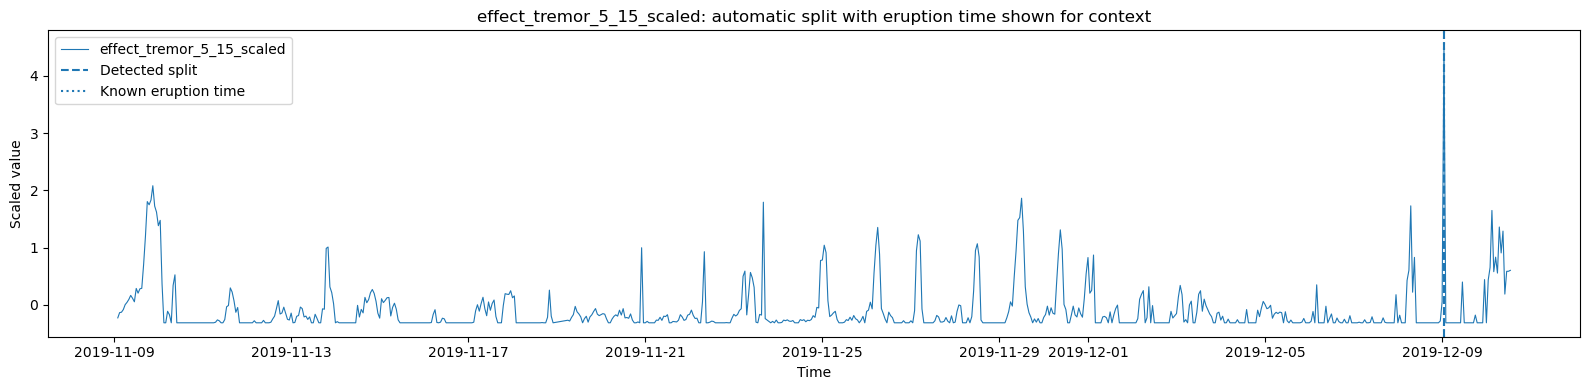

In [ ]:
reference_parameters = reference_parameter_table(
    X,
    EFFECT,
    max_lags=MAX_LAGS,
    fallback_lag=1,
    fallback_distribution="gaussian",
)
display(reference_parameters)

selected_lag = int(reference_parameters.loc[
    reference_parameters["lag_method"].eq("VAR-AIC"),
    "selected_lag"
].iloc[0])

workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    distribution="gaussian",
    parameter_source="reference_metadata",
    run_specs=COMPACT_RUN_SPECS,
)

split_row = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([split_row]))

plot_effect_with_split(
    X,
    EFFECT,
    split_row,
    event_time=EVENT_TIME,
)

## 3. Backend and lag grid

This section runs HMML, PCMCI, and PCMCI+ over lags 1--12.

The first table expands accepted cause--trigger pairs into one row per pair. The second table keeps rows with any backend signal: non-empty \(B_2\), trigger candidates, accepted triggers, accepted pairs, or PCMCI+ contemporaneous links.

Main columns: `B_2` = selected lagged parents of the effect; `trigger_candidates` = variables eligible for moderation testing; `accepted_triggers` = candidates passing the F-test; `pairs` = final cause--trigger pairs.

In [ ]:
grid_all = run_sensitivity_grid(
    X,
    workflow,
    run_specs=COMPACT_RUN_SPECS,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

pair_rows = expand_pair_outputs(grid_all)
signal_rows = compact_grid_outputs(grid_all, mode="signals")
error_rows = compact_grid_errors(grid_all)

print(f"All grid rows: {len(grid_all)}")
print(f"Rows with accepted pairs: {len(pair_rows)}")
print(f"Rows with any backend signal: {len(signal_rows)}")
print(f"Rows with backend errors: {len(error_rows)}")

display(pair_rows)
display(signal_rows)

if not error_rows.empty:
    display(error_rows)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfec

All grid rows: 36
Rows with accepted pairs: 4
Rows with any backend signal: 24


,backend,lag,cause,trigger,split_timestamp,I1_length,I2_length,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links
0,hmml,3,SO2_flux_scaled,ratio_4p5_8_over_8_16_scaled,2019-12-09 01:00:00+00:00,712,37,0.008765,0.201602,0
1,hmml,6,ratio_4p5_8_over_8_16_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,712,37,0.011048,0.209192,0
2,hmml,8,SO2_flux_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,712,37,0.000099,0.447564,0
3,hmml,9,ratio_4p5_8_over_8_16_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,712,37,0.000002,0.610458,0


,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,hmml_backend_beta,hmml,1,gaussian,2019-12-09 01:00:00+00:00,712,37,"[SO2_flux_scaled, GNSS_deformation_scaled]",[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],[],1.000000,0.000000,0,None
1,hmml_backend_beta,hmml,2,gaussian,2019-12-09 01:00:00+00:00,712,37,"[SO2_flux_scaled, GNSS_deformation_scaled]",[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],[],1.000000,0.000000,0,None
2,hmml_backend_beta,hmml,3,gaussian,2019-12-09 01:00:00+00:00,712,37,"[ratio_4p5_8_over_8_16_scaled, SO2_flux_scaled, GNSS_deformation_scaled]","[ratio_4p5_8_over_8_16_scaled, SO2_flux_scaled]","[ratio_4p5_8_over_8_16_scaled, SO2_flux_scaled]",[],[ratio_4p5_8_over_8_16_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, ratio_4p5_8_over_8_16_scaled)]",0.008765,0.201602,0,None
3,hmml_backend_beta,hmml,4,gaussian,2019-12-09 01:00:00+00:00,712,37,"[SO2_flux_scaled, GNSS_deformation_scaled]",[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],[],1.000000,0.000000,0,None
4,hmml_backend_beta,hmml,5,gaussian,2019-12-09 01:00:00+00:00,712,37,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, SO2_flux_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, SO2_flux_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, SO2_flux_scaled]",[],[],[],[],0.187342,0.059159,0,None
5,hmml_backend_beta,hmml,6,gaussian,2019-12-09 01:00:00+00:00,712,37,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, pressure_drop_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, pressure_drop_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, pressure_drop_scaled]",[],[hydro_2_5_scaled],[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled)]",0.011048,0.209192,0,None
6,hmml_backend_beta,hmml,7,gaussian,2019-12-09 01:00:00+00:00,712,37,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, GNSS_deformation_scaled]","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]",[],[],[],[],0.299228,0.039840,0,None
7,hmml_backend_beta,hmml,8,gaussian,2019-12-09 01:00:00+00:00,712,37,"[hydro_2_5_scaled, pressure_drop_scaled, SO2_flux_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, pressure_drop_scaled, SO2_flux_scaled]","[hydro_2_5_scaled, pressure_drop_scaled, SO2_flux_scaled]",[],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",0.000099,0.447564,0,None
8,hmml_backend_beta,hmml,9,gaussian,2019-12-09 01:00:00+00:00,712,37,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]",[],[hydro_2_5_scaled],[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled)]",0.000002,0.610458,0,None
9,hmml_backend_beta,hmml,10,gaussian,2019-12-09 01:00:00+00:00,712,37,"[hydro_2_5_scaled, SO2_flux_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, SO2_flux_scaled]","[hydro_2_5_scaled, SO2_flux_scaled]",[],[],[],[],0.318472,0.041453,0,None


## 4. Reference-lag comparison

This final table shows the backend outputs at the VAR-AIC reference lag only. It is included for transparency, but the main interpretation should come from the lag grid above.

In the diagnostics table, `accepted=True` means that a candidate trigger passed the moderation F-test for that backend, lag, split, and window.

In [ ]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    run_specs=COMPACT_RUN_SPECS,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

display(compact_comparison(comparison))
display(compact_diagnostics(diagnostics))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)


,run,backend,configured_lags,configured_distribution,split_timestamp,I1_length,I2_length,B2,trigger_candidates,accepted_triggers,causes,pairs,stop_reason
0,hmml_backend_beta,hmml,4,gaussian,2019-12-09 01:00:00+00:00,712,37,"[SO2_flux_scaled, GNSS_deformation_scaled]",[SO2_flux_scaled],[],[],[],None
1,pcmci_ridge,pcmci,4,gaussian,2019-12-09 01:00:00+00:00,712,37,[],[],[],[],[],No lagged non-target B2 variables available to construct V.
2,pcmci_plus_ridge,pcmci_plus,4,gaussian,2019-12-09 01:00:00+00:00,712,37,[],[],[],[],[],No lagged non-target B2 variables available to construct V.


,run,trigger,cause,accepted,p_value,f_stat,critical_f,rss_reduction_ratio,gamma_2,backend
0,hmml_backend_beta,SO2_flux_scaled,GNSS_deformation_scaled,False,1.0,0.0,4.170877,0.0,0.417077,hmml
